In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import os
%matplotlib inline

base_path = '/work/hawkins_lab/vulcan/data/vulcan'

# Transportation

In [2]:
tran_par_file = os.path.join(base_path,'parquet','vulcan_ONR_epa_climate.parquet')
df = gpd.read_parquet(tran_par_file)

# Create columns that assign quintile numbers for each treatment variable
df['treat_density'] = df['d1a']
df['treat_diversity'] = df['d2b_e5mixa']
df['treat_design'] = df['d3a']
df['d4a'] = df['d4a'].fillna(0)
df['treat_distance'] = df['d4a']
df['treat_destination'] = df['d5ar']

In [3]:
df.loc[:,['treat_design','treat_destination']].describe()

,treat_design,treat_destination
count,216290.000000,2.162900e+05
mean,15.779906,1.049770e+05
std,10.706782,1.540355e+05
min,0.000000,0.000000e+00
25%,5.628356,1.010600e+04
50%,15.655748,4.458350e+04
75%,23.376650,1.275582e+05
max,166.894521,1.220602e+06


In [4]:
var_list = ['p_highschool','p_owner','pct_ao0','avg_hh_size',
 'med_dwelling_age','totpop_cbsa', 'stc2erta', 'w_p_lowwag', 'gasprice', 'vmt_per_wo', 'annual_ghg',
  'treat_density', 'treat_diversity', 'treat_design', 'treat_distance', 'treat_destination']

df.loc[:,var_list].fillna(method="ffill").isna().sum()

/tmp/ipykernel_2120080/3535286984.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.loc[:,var_list].fillna(method="ffill").isna().sum()


p_highschool         0
p_owner              0
pct_ao0              0
avg_hh_size          0
med_dwelling_age     0
totpop_cbsa          0
stc2erta             0
w_p_lowwag           0
gasprice             0
vmt_per_wo           0
annual_ghg           0
treat_density        0
treat_diversity      0
treat_design         0
treat_distance       0
treat_destination    0
dtype: int64

In [5]:
# Compute correlation matrix
corr_matrix = df.loc[:,var_list].corr(method="pearson")

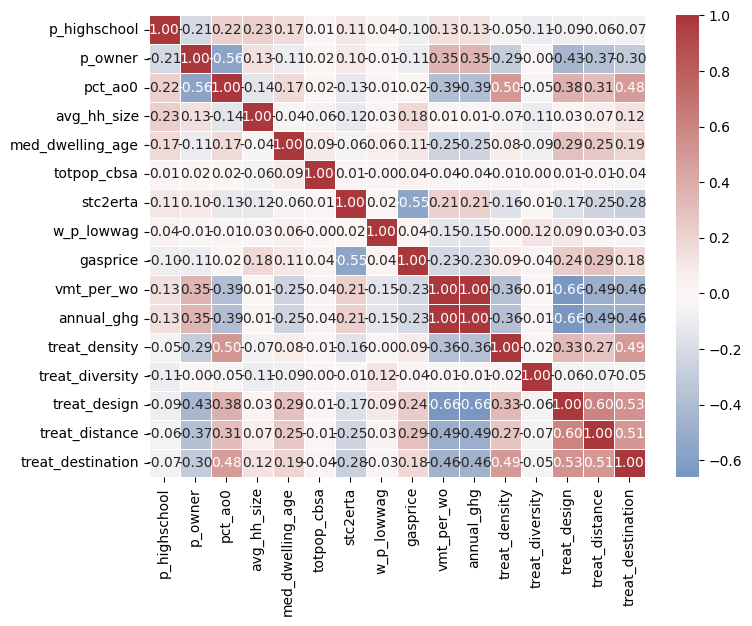

In [6]:
# Set up the figure size
plt.figure(figsize=(8, 6))

# Create heatmap
sns.heatmap(corr_matrix, annot=True, cmap="vlag", fmt=".2f", linewidths=0.5, center=0)

# Title
# plt.title("Pearson Correlation Heatmap", fontsize=14)
plt.savefig("/work/hawkins_lab/vulcan/results/transport_heatmap.pdf", format='pdf')

In [9]:
imp_df = pd.read_csv('/work/hawkins_lab/vulcan/results/importance_transport.csv')

In [10]:
df_agg = imp_df.groupby(['Segment', 'Treatment', 'Feature'], group_keys=False).agg(
    min_importance=('Importance', 'min'),
    median_importance=('Importance', 'median'),
    sum_importance=('Importance', 'sum')
).reset_index()  # Ensure Segment, Treatment, and Feature are columns

# Step 1: Compute the total sum_importance per (Segment, Treatment) group
group_order = df_agg.groupby(['Segment', 'Treatment'], as_index=False)['sum_importance'].sum()

# Step 2: Sort the groups by sum_importance in descending order
group_order = group_order.sort_values(by='sum_importance', ascending=False)[['Segment', 'Treatment']]

# Step 3: Merge sorted group order back into df_agg to preserve order
df_sorted = group_order.merge(df_agg, on=['Segment', 'Treatment']).sort_values(by=['Segment', 'Treatment', 'sum_importance'], ascending=[False, False, False])

print(df_sorted.set_index(['Segment', 'Treatment', 'Feature']))

                                    min_importance  median_importance  \
Segment Treatment Feature                                               
transpo div       annual_ghg              0.043468           0.396404   
                  vmt_per_wo              0.035055           0.087291   
                  med_dwelling_age        0.056352           0.172517   
                  w_p_lowwag              0.034061           0.089187   
                  pct_ao0                -0.000728           0.003820   
                  totpop_cbsa            -0.003667           0.000205   
                  p_highschool           -0.004364          -0.001757   
                  avg_hh_size            -0.008171          -0.002527   
                  stc2erta               -0.008151          -0.001284   
                  gasprice               -0.007676          -0.001854   
        dist      vmt_per_wo              0.397065           0.399828   
                  med_dwelling_age        0.276344 

We can prioritize inclusion in the PS based on comparison of the minimum and median importance scores (relative contributions to R2).

**For transport CO2 and density:**
1. med_dwelling_age
2. w_p_lowwag
3. p_highschool
4. gasprice
5. pct_ao0
6. stc2erta
7. avg_hh_size

Remaining are quite low (<0.05, or 0.01 per quintile):

8. annual_ghg
9. totpop_cbsa
10. vmt_per_wo

**For transport CO2 and design:**
1. med_dwelling_age
2. w_p_lowwag
3. annual_ghg
4. vmt_per_wo
5. gasprice
6. p_highschool
7. stc2erta
8. pct_ao0
9. avg_hh_size

Remaining are quite low (<0.05, or 0.01 per quintile):

9. totpop_cbsa

**For transport CO2 and destination:**
1. vmt_per_wo
2. med_dwelling_age
3. annual_ghg
4. w_p_lowwag
5. pct_ao0
6. avg_hh_size 
   
Remaining are quite low (<0.05, or 0.01 per quintile):

7. stc2erta
8. totpop_cbsa
9. p_highschool
10. gasprice
   
**For transport CO2 and distance to transit:**
1. vmt_per_wo
2. med_dwelling_age
3. w_p_lowwag
4. annual_ghg

Remaining are quite low (<0.05, or 0.01 per quintile):

5. pct_ao0
6. totpop_cbsa
7. avg_hh_size
8. gasprice
9. p_highschoo
10. stc2erta

**For transport CO2 and diversity:**
1. annual_ghg
2. vmt_per_wo
3. med_dwelling_age
4. w_p_lowwag
5. pct_ao0

Remaining are quite low (<0.05, or 0.01 per quintile):

6. totpop_cbsa
7. p_highschool
8. avg_hh_size
9. stc2erta
10. gasprice